## Setup environment

In [ ]:
!pip install git+https://github.com/justindomke/pangolin.git
!pip install --upgrade jax==0.9.0 jaxlib==0.9.0

  Cloning https://github.com/justindomke/pangolin.git to /tmp/pip-req-build-6g5pbxfj
  Running command git clone --filter=blob:none --quiet https://github.com/justindomke/pangolin.git /tmp/pip-req-build-6g5pbxfj
  Resolved https://github.com/justindomke/pangolin.git to commit 2507477c7fbc29f81ab5e1e82972154b98ca86f9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 146.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 10.9 MB/s eta 0:00:00
  Created wheel for pangolin: filename=pangolin-0.0.3-py3-none-any.whl size=143651 sha256=db1cb6458cafa247fdc5001a4a3f56b7c30ccdf6090de909162c1da730b38a6d

In [ ]:
import numpy as np
import pandas as pd
import pangolin as pg
import pangolin.interface as pi
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

## Simulate data

In [ ]:
N = 100

In [ ]:
α = pi.constant(10)
β = pi.constant(2)
σ = pi.constant(5)
x = [pi.constant(i) for i in range(N)]
μ = [α + β * x[i] for i in range(N)]
y = [pi.normal(μ[i], σ) for i in range(N)]

In [ ]:
y_sim = pg.blackjax.sample(y)

/usr/local/lib/python3.12/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (100), generating only 20 plots
  warnings.warn(


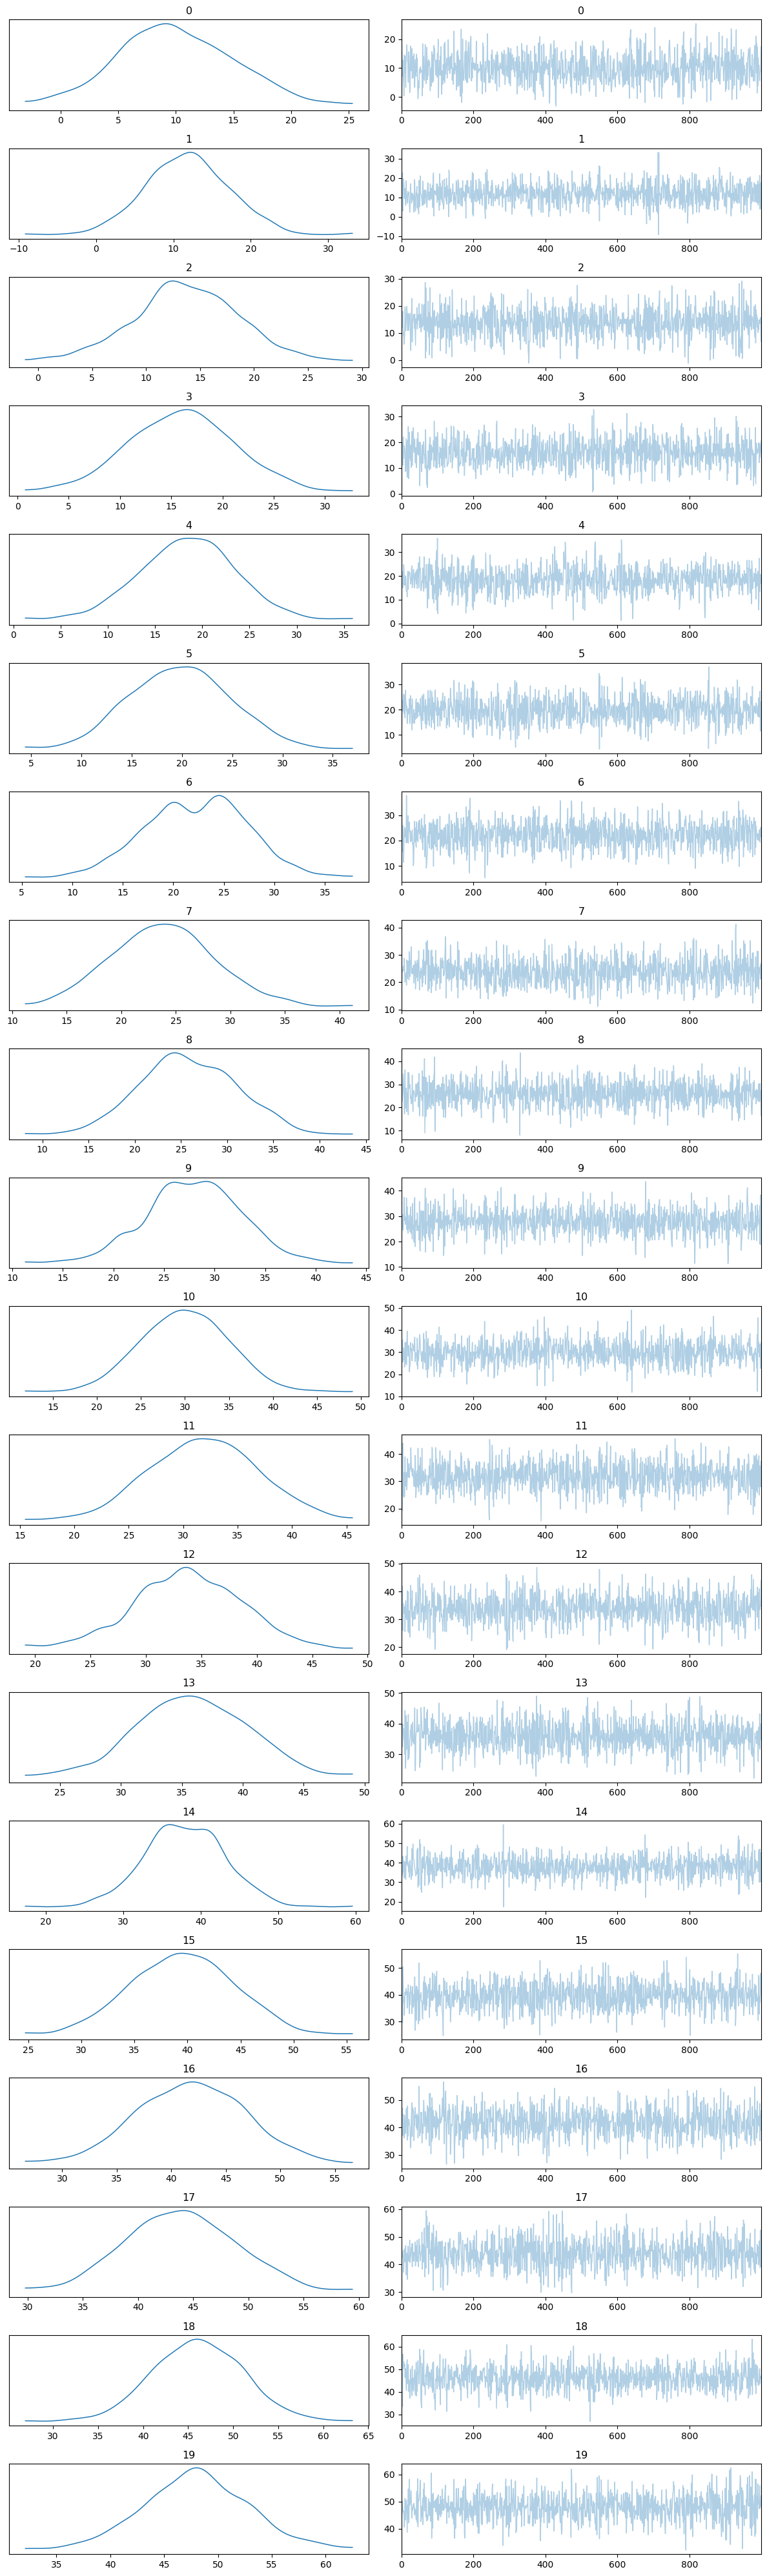

In [ ]:
y_sim_az = az.from_dict(dict(zip(range(N), y_sim)))
az.plot_trace(y_sim_az)
plt.tight_layout()
plt.show()

## Prior

In [ ]:
α = pi.normal(0, 100)
β = pi.normal(0, 10)
σ = pi.exponential(0.1)
x = [pi.constant(i) for i in range(N)]
μ = [α + β * x[i] for i in range(N)]
y = [pi.normal(μ[i], σ) for i in range(N)]
y_pred = [pi.normal(μ[i], σ) for i in range(N)]

In [ ]:
prior = pg.blackjax.sample([α, β, σ])

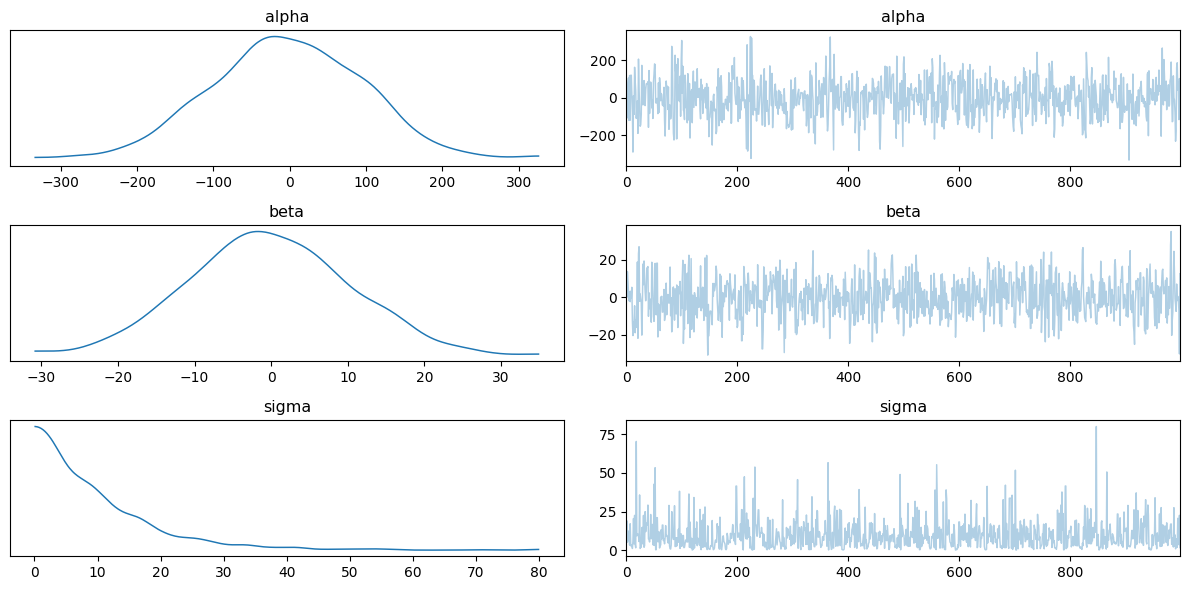

In [ ]:
prior_az = az.from_dict(dict(zip(["alpha", "beta", "sigma"], prior)))
az.plot_trace(prior_az)
plt.tight_layout()
plt.show()

## Prior predictive

In [ ]:
y_prior_pred = pg.blackjax.sample(y_pred)

/usr/local/lib/python3.12/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (100), generating only 20 plots
  warnings.warn(


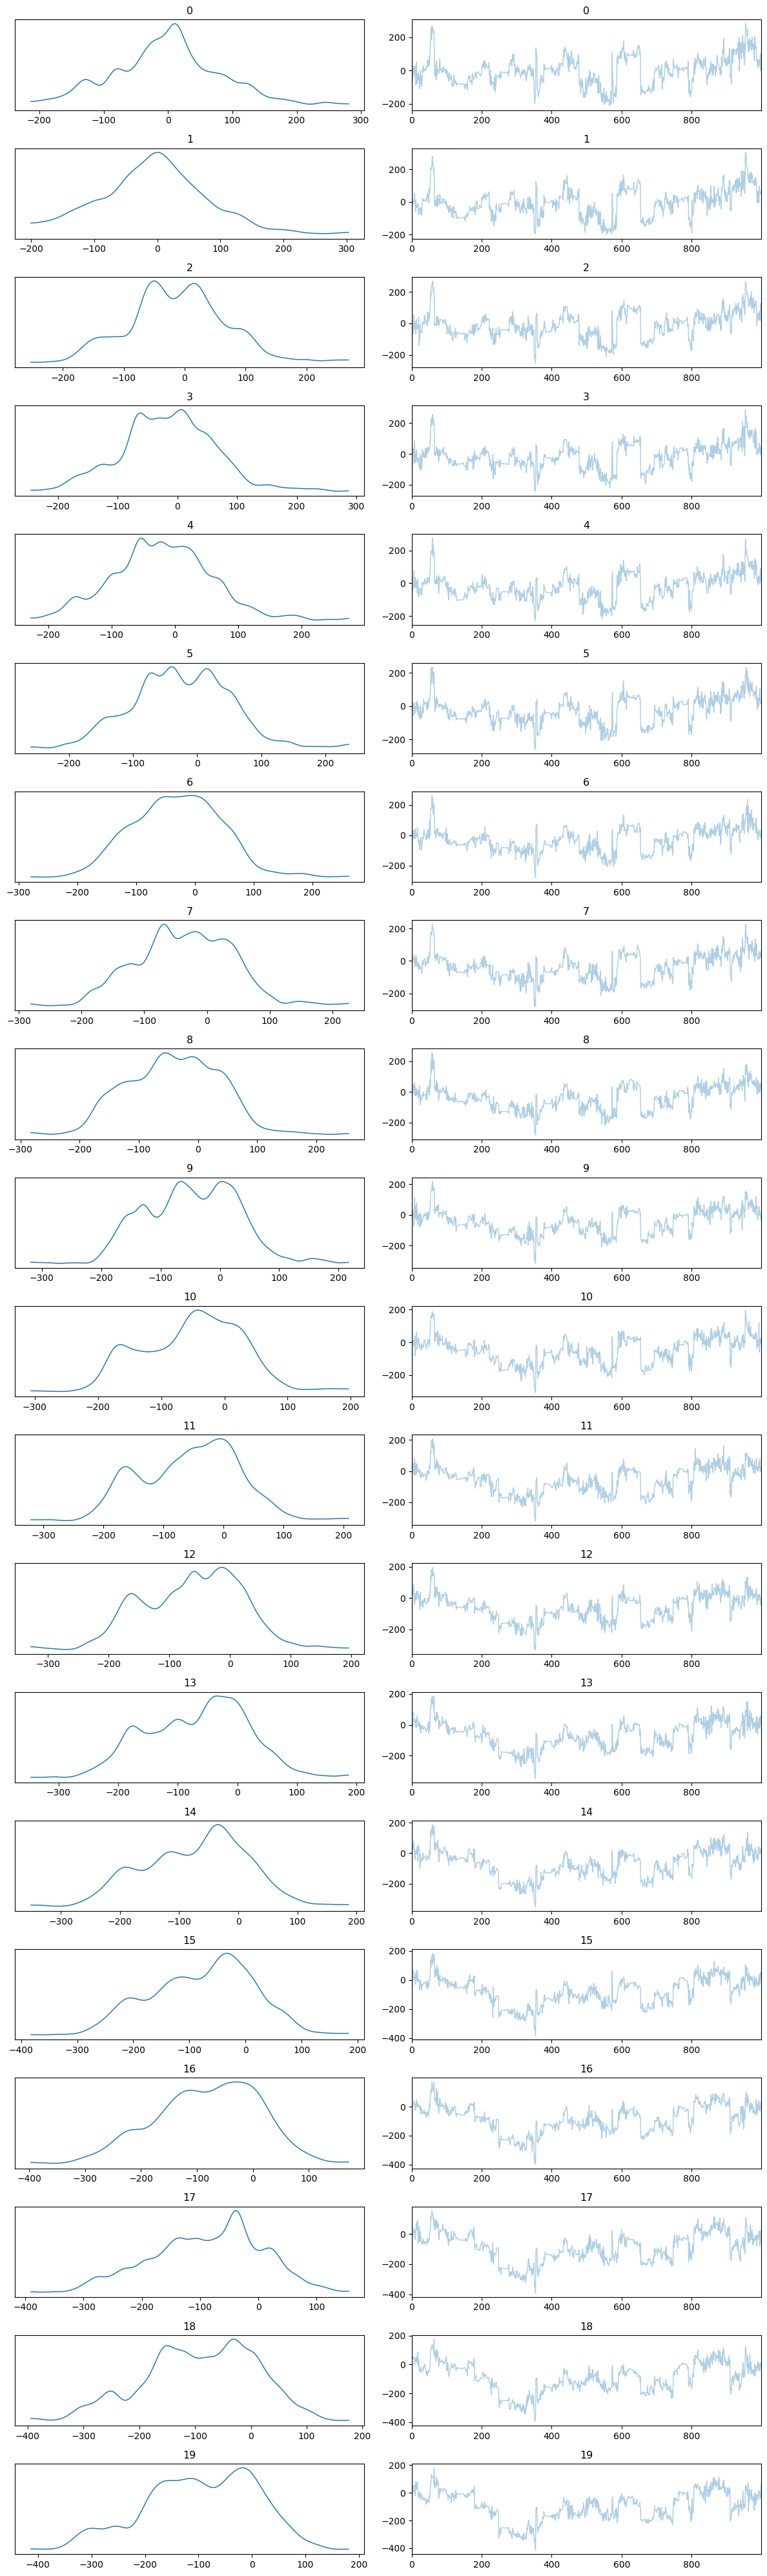

In [ ]:
y_prior_pred_az = az.from_dict(dict(zip(range(N), y_prior_pred)))
az.plot_trace(y_prior_pred_az)
plt.tight_layout()
plt.show()

## Posterior

In [ ]:
y_obs = [y_sim[i][0] for i in range(N)]

In [ ]:
post = pg.blackjax.sample([α, β, σ], y, y_obs)

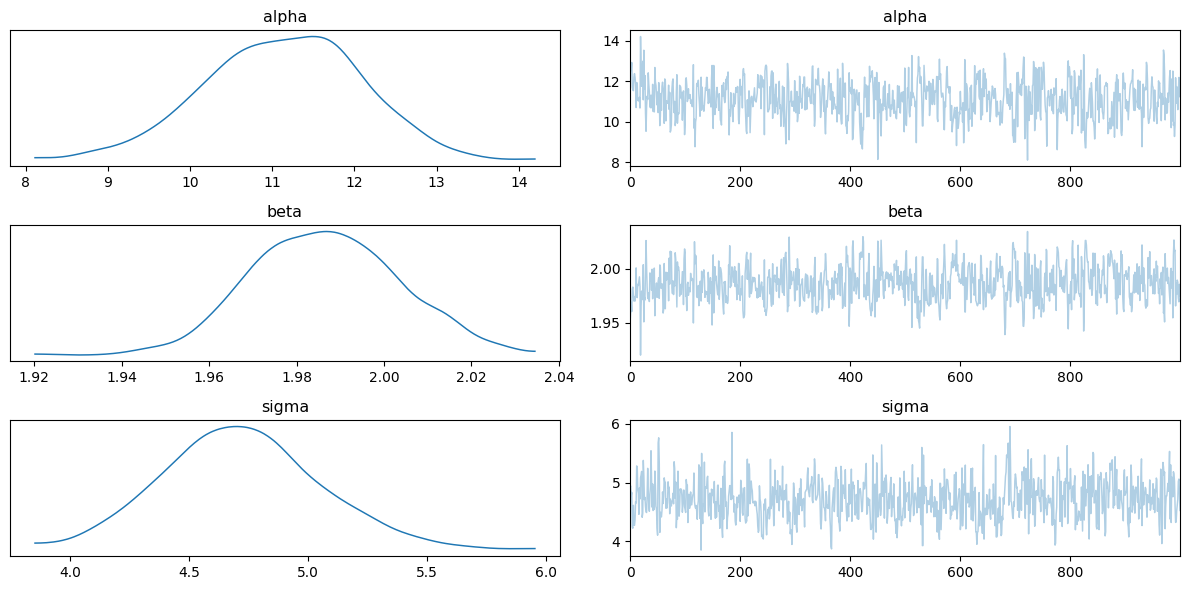

In [ ]:
post_az = az.from_dict(dict(zip(["alpha", "beta", "sigma"], post)))
az.plot_trace(post_az)
plt.tight_layout()
plt.show()

## Posterior predictive

In [ ]:
y_post_pred = pg.blackjax.sample(y_pred, y, y_obs)

/usr/local/lib/python3.12/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (100), generating only 20 plots
  warnings.warn(


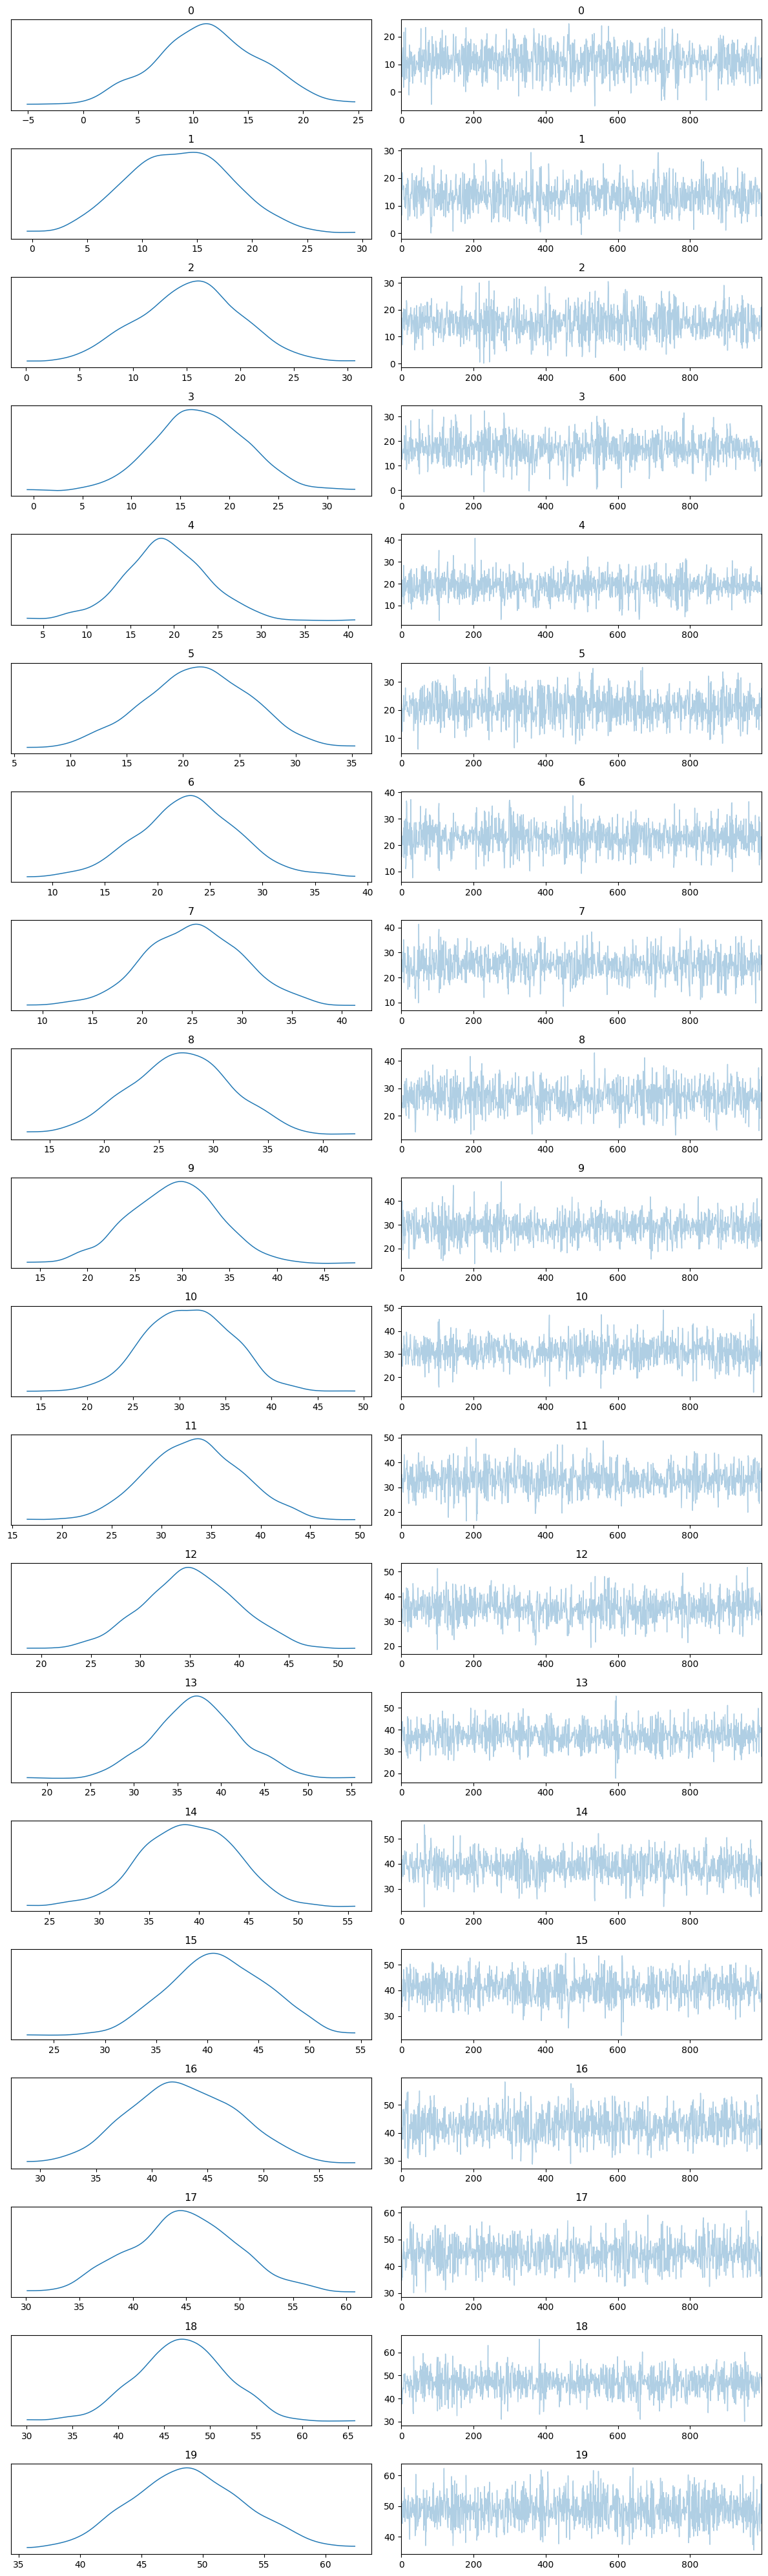

In [ ]:
y_post_pred_az = az.from_dict(dict(zip(range(N), y_post_pred)))
az.plot_trace(y_post_pred_az)
plt.tight_layout()
plt.show()